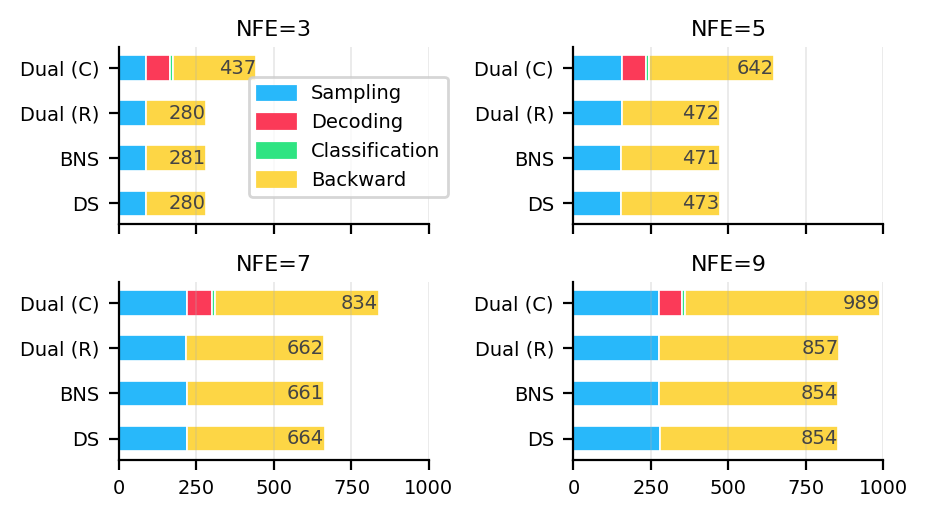

In [3]:
# Update: show totals using truncation (floor), not rounding.
# Re-render the same 2x2 figure with floor for labels.

import numpy as np
import matplotlib.pyplot as plt
import math

PALETTES = {
    "journal_printsafe": {
        "Sampling":  "#28B8FA",
        "Decoding":  "#FB3A58",
        "Classification":"#2FE482",
        "Backward":  "#FDD645",
    },
}

data = {
    3: {
        "Dual (C)":[85.85, 77.86, 3.76, 269.92],
        "Dual (R)":[87.18, 0.00, 0.00, 193.64],
        "BNS":[88.70, 0.00, 0.00, 192.49],
        "DS":[87.88, 0.00, 0.00, 192.74],
    },
    5: {
        "Dual (C)":[155.80, 79.34, 5.06, 402.76],
        "Dual (R)":[155.42, 0.00, 0.00, 316.88],
        "BNS":[153.99, 0.00, 0.00, 317.24],
        "DS":[154.28, 0.00, 0.00, 319.20],
    },
    7: {
        "Dual (C)":[220.97, 79.39, 6.54, 527.97],
        "Dual (R)":[215.72, 0.00, 0.00, 447.22],
        "BNS":[218.91, 0.00, 0.00, 442.33],
        "DS":[219.47, 0.00, 0.00, 444.70],
    },
    9: {
        "Dual (C)":[274.55, 76.77, 8.94, 629.14],
        "Dual (R)":[277.02, 0.00, 0.00, 580.17],
        "BNS":[276.60, 0.00, 0.00, 577.61],
        "DS":[278.49, 0.00, 0.00, 576.50],
    },
}

palette = PALETTES["journal_printsafe"]
comps = ["Sampling","Decoding","Classification","Backward"]
labels = ["Dual (C)","Dual (R)","BNS","DS"]

def draw_panel(ax, nfe, *, xlim=(0,1000), row_spacing=0.56, bar_height=0.32):
    base = np.arange(len(labels))[::-1]
    y = base * row_spacing

    for idx, solver in enumerate(labels):
        left_plot = 0.0
        left_true = 0.0

        for comp, w in zip(comps, data[nfe][solver]):
            if solver != "Dual (C)" and comp in ("Decoding","Classification"):
                left_true += w
                continue

            plot_w = max(w, 10.0) if (solver == "Dual (C)" and comp == "Classification") else w

            if plot_w > 0:
                ax.barh(y[idx], plot_w, height=bar_height, left=left_plot,
                        color=palette[comp], edgecolor="white", linewidth=0.6)
                left_plot += plot_w

            left_true += w

        # Use floor (truncation) for the displayed total
        tx = max(0, left_plot - 2.0)
        ax.text(tx, y[idx], f"{math.floor(left_true)}", va="center", ha="right",
                fontsize=7, color="#444444", clip_on=True)

    ax.set_yticks(y); ax.set_yticklabels(labels)
    ax.grid(axis="x", linestyle="-", linewidth=0.6, alpha=0.3)
    ax.set_title(f"NFE={nfe}", fontsize=8, pad=4)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.set_xlim(*xlim)

plt.rcParams.update({"figure.dpi":200,"font.size":7,"axes.linewidth":0.8,"mathtext.fontset":"cm"})
fig, axes = plt.subplots(2,2, figsize=(5.0,2.6), sharex=True)
axes = axes.ravel()

for ax, nfe in zip(axes, [3,5,7,9]):
    draw_panel(ax, nfe)

for ax in axes:
    ax.set_xlim(0, 1000)
    ax.set_xticks([0,250,500,750,1000])

handles = [plt.Rectangle((0,0),1,1,color=palette[k]) for k in ["Sampling","Decoding","Classification","Backward"]]
fig.legend(handles, ["Sampling","Decoding","Classification","Backward"],
           loc="lower left", bbox_to_anchor=(0.24,0.60), frameon=True, fontsize=7)

plt.tight_layout(rect=[0.0,0.0,0.93,1.0])
plt.show()


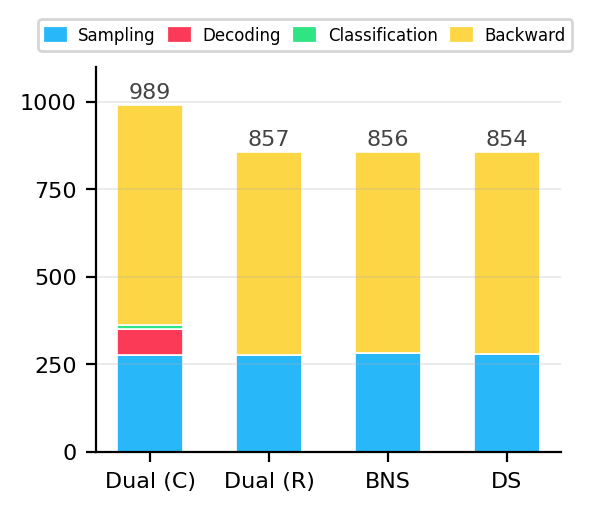

In [24]:
# Vertical (stacked) version for NFE=9 with legend.
# Rules:
# - Classification drawn only for Dual (C), with min visible height = 10 ms
# - Decoding/Classification omitted for Dual (R), BNS, DS
# - Total label uses truncation (floor)

import numpy as np
import matplotlib.pyplot as plt
import math

PALETTES = {
    "journal_printsafe": {
        "Sampling":  "#28B8FA",
        "Decoding":  "#FB3A58",
        "Classification":"#2FE482",
        "Backward":  "#FDD645",
    },
}

data = {
    9: {
        "Dual (C)":[274.55, 76.77, 8.94, 629.14],
        "Dual (R)":[277.02, 0.00, 0.00, 580.17],
        "BNS":[280.55, 0.00, 0.00, 576.24],
        "DS":[278.49, 0.00, 0.00, 576.50],
    },
}

palette = PALETTES["journal_printsafe"]
comps = ["Sampling","Decoding","Classification","Backward"]
labels = ["Dual (C)","Dual (R)","BNS","DS"]

plt.rcParams.update({"figure.dpi":200,"font.size":8,"axes.linewidth":0.8,"mathtext.fontset":"cm"})
fig, ax = plt.subplots(figsize=(3.0, 2.6))

x = np.arange(len(labels))
bar_width = 0.55

# Draw stacked vertical bars
for i, solver in enumerate(labels):
    bottom_plot = 0.0
    total_true = 0.0
    for comp, w in zip(comps, data[9][solver]):
        # Only show Decoding/Classification for Dual (C)
        if solver != "Dual (C)" and comp in ("Decoding","Classification"):
            total_true += w
            continue

        # Min visible height for Classification in Dual (C)
        h = max(w, 10.0) if (solver == "Dual (C)" and comp == "Classification") else w

        if h > 0:
            ax.bar(x[i], h, width=bar_width, bottom=bottom_plot,
                   color=palette[comp], edgecolor="white", linewidth=0.6)
            bottom_plot += h

        total_true += w

    # Total label (floor)
    ax.text(x[i], bottom_plot + 8, f"{math.floor(total_true)}", ha="center", va="bottom",
            fontsize=8, color="#444444", clip_on=True)

# Axes / ticks
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=0)
ax.set_ylim(0, 1100)
ax.set_yticks([0,250,500,750,1000])
ax.grid(axis="y", linestyle="-", linewidth=0.6, alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend
handles = [plt.Rectangle((0,0),1,1,color=palette[k]) for k in ["Sampling","Decoding","Classification","Backward"]]
ax.legend(handles, ["Sampling","Decoding","Classification","Backward"],
          loc="lower center", bbox_to_anchor=(0.45, 1.02), ncol=4, frameon=True,
          fontsize=6.0, handlelength=1.2, columnspacing=0.8)

plt.tight_layout()
plt.show()
